# Corporacion Favorita - Analisis Exploratorio de Datos

**Dataset:** Corporacion Favorita Grocery Sales Forecasting (Kaggle)

**Fuente:** Cadena de supermercados real de Ecuador, datos 2013 a 2017

**Objetivo del proyecto:** Entender los patrones de demanda de alimentos para mejorar el abastecimiento logistico del albergue ALDIMI

---

### Archivos del dataset

| Archivo | Filas | Descripcion |
|---|---|---|
| `items.csv` | 4,100 | Productos con familia, clase y si son perecibles |
| `stores.csv` | 54 | Tiendas con ciudad, estado, tipo y cluster |
| `oil.csv` | 1,218 | Precio diario del petroleo en Ecuador |
| `holidays_events.csv` | 350 | Festivos y eventos con tipo y alcance geografico |
| `transactions.csv` | 83,488 | Transacciones diarias por tienda |
| `train.csv` | ~125M | Ventas diarias por tienda-producto (5 GB, se descarga aparte) |

## Paso 0 - Instalacion de librerias

In [ ]:
!pip install pandas numpy matplotlib seaborn missingno scipy kaggle -q
print('Librerias instaladas')

Librerias instaladas


## Paso 1 - Importacion de librerias y carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

# Ajustar BASE si los archivos estan en una subcarpeta
BASE = ''

items        = pd.read_csv(f'{BASE}items.csv')
stores       = pd.read_csv(f'{BASE}stores.csv')
oil          = pd.read_csv(f'{BASE}oil.csv',             parse_dates=['date'])
holidays     = pd.read_csv(f'{BASE}holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(f'{BASE}transactions.csv',    parse_dates=['date'])

print('Archivos auxiliares cargados:')
print(f'  items:        {items.shape}')
print(f'  stores:       {stores.shape}')
print(f'  oil:          {oil.shape}')
print(f'  holidays:     {holidays.shape}')
print(f'  transactions: {transactions.shape}')

Archivos auxiliares cargados:
  items:        (4100, 4)
  stores:       (54, 5)
  oil:          (1218, 2)
  holidays:     (350, 6)
  transactions: (83488, 3)


In [ ]:
!p7zip -d '/content/train.csv.7z'


7-Zip (a) [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 474092593 bytes (453 MiB)

Extracting archive: /content/train.csv.7z
--
Path = /content/train.csv.7z
Type = 7z
Physical Size = 474092593
Headers Size = 122
Method = LZMA2:24
Solid = -
Blocks = 1

  0%      0% - train.csv                  1% - train.csv                  2% - train.csv                  3% - train.csv                  4% - train.csv                  5% - train.csv                  6% - train.csv                  7% - train.csv

In [ ]:
# Carga de train.csv en muestra para hacer el EDA de forma rapida
# El archivo completo tiene ~125 millones de filas y pesa 5 GB
# Para el EDA se usan 3 millones de filas que son representativos
# Para el modelado final se debe usar el archivo completo

print('Cargando muestra de train.csv (3 millones de filas)...')
train = pd.read_csv(
    'train.csv',
    parse_dates=['date'],
    dtype={'store_nbr': 'int8', 'item_nbr': 'int32'},
    nrows=3_000_000
)

# Unir con items para tener la familia y si es perecible
train = train.merge(items[['item_nbr','family','perishable']], on='item_nbr', how='left')
# Unir con stores para tener ciudad y tipo de tienda
train = train.merge(stores[['store_nbr','city','state','type']], on='store_nbr', how='left')

# Las ventas negativas son devoluciones, no demanda, se convierten a 0
train['unit_sales'] = train['unit_sales'].clip(lower=0)

print(f'Train cargado: {len(train):,} filas x {train.shape[1]} columnas')
print(f'Fechas: {train["date"].min().date()} a {train["date"].max().date()}')
print(f'Tiendas: {train["store_nbr"].nunique()}  Items: {train["item_nbr"].nunique()}  Familias: {train["family"].nunique()}')
train.head(3)

Cargando muestra de train.csv (3 millones de filas)...
Train cargado: 3,000,000 filas x 11 columnas
Fechas: 2013-01-01 a 2013-03-15
Tiendas: 46  Items: 1642  Familias: 21


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,perishable,city,state,type
0,0,2013-01-01,25,103665,7.0,NaN,BREAD/BAKERY,1,Salinas,Santa Elena,D
1,1,2013-01-01,25,105574,1.0,NaN,GROCERY I,0,Salinas,Santa Elena,D
2,2,2013-01-01,25,105575,2.0,NaN,GROCERY I,0,Salinas,Santa Elena,D


---
## Paso 2 - Vista general del dataset

Cada fila de train representa la venta de un producto en una tienda en un dia. Las columnas principales son: `date`, `store_nbr`, `item_nbr`, `unit_sales` y `onpromotion`.

In [ ]:
tablas = [
    ('items',        items,        'Catalogo de productos'),
    ('stores',       stores,       'Catalogo de tiendas'),
    ('oil',          oil,          'Precio del petroleo'),
    ('holidays',     holidays,     'Festivos y eventos'),
    ('transactions', transactions, 'Transacciones por tienda'),
    ('train',        train,        'Ventas diarias (muestra 3M)'),
]

print('RESUMEN DE TABLAS')
print('=' * 60)
for nombre, df, desc in tablas:
    nulos = df.isnull().sum().sum()
    print(f'  {nombre:<14} {df.shape[0]:>8,} filas x {df.shape[1]:>2} cols   nulos: {nulos:>5}   {desc}')

print()
print('Tipos de datos en train:')
print(train.dtypes.to_string())
print()
print('Estadisticas descriptivas de variables numericas en train:')
print(train[['unit_sales','onpromotion','perishable']].describe().round(3).to_string())

RESUMEN DE TABLAS
  items             4,100 filas x  4 cols   nulos:     0   Catalogo de productos
  stores               54 filas x  5 cols   nulos:     0   Catalogo de tiendas
  oil               1,218 filas x  2 cols   nulos:    43   Precio del petroleo
  holidays            350 filas x  6 cols   nulos:     0   Festivos y eventos
  transactions     83,488 filas x  3 cols   nulos:     0   Transacciones por tienda
  train          3,000,000 filas x 11 cols   nulos: 3000000   Ventas diarias (muestra 3M)

Tipos de datos en train:
id                      int64
date           datetime64[ns]
store_nbr                int8
item_nbr                int32
unit_sales            float64
onpromotion           float64
family                 object
perishable              int64
city                   object
state                  object
type                   object

Estadisticas descriptivas de variables numericas en train:
        unit_sales  onpromotion   perishable
count  3000000.000          0.

---
## Paso 3 - Analisis de valores nulos

El unico problema real de nulos en este dataset esta en el precio del petroleo, que tiene 43 fechas sin valor porque los mercados financieros no cotizan los fines de semana ni en dias feriados bursatiles.

NULOS POR TABLA
--------------------------------------------------
items: sin valores nulos
stores: sin valores nulos

oil:
  dcoilwtico                    43 nulos (3.5%)
holidays: sin valores nulos
transactions: sin valores nulos

train:
  onpromotion               3000000 nulos (100.0%)


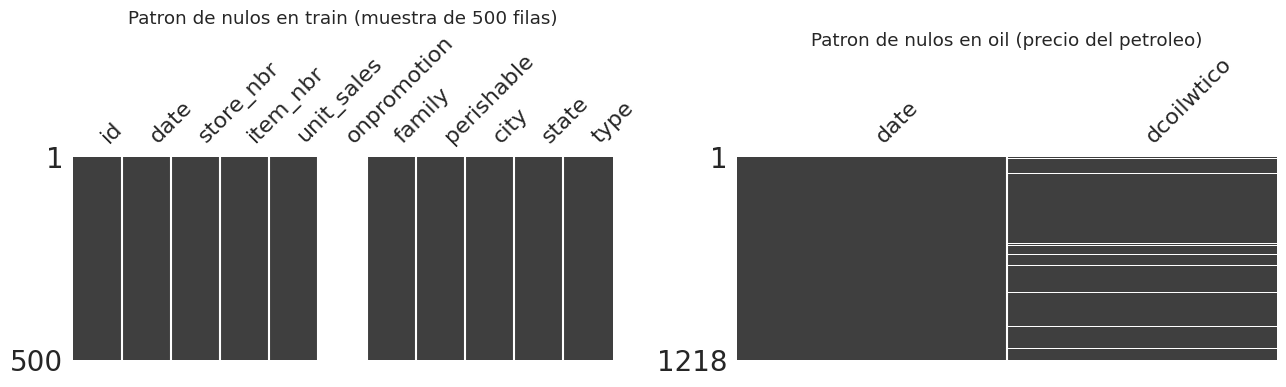

Nulos en oil despues de imputacion: 0


In [ ]:
print('NULOS POR TABLA')
print('-' * 50)
for nombre, df, _ in tablas:
    nulos_col = df.isnull().sum()
    if nulos_col.sum() > 0:
        print(f'\n{nombre}:')
        for col, n in nulos_col[nulos_col > 0].items():
            print(f'  {col:<25} {n:>6} nulos ({n/len(df)*100:.1f}%)')
    else:
        print(f'{nombre}: sin valores nulos')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

msno.matrix(train.sample(min(500, len(train)), random_state=SEED),
            ax=axes[0], sparkline=False)
axes[0].set_title('Patron de nulos en train (muestra de 500 filas)')

msno.matrix(oil, ax=axes[1], sparkline=False)
axes[1].set_title('Patron de nulos en oil (precio del petroleo)')

plt.tight_layout()
plt.show()

# Imputacion
# Se usa forward fill: el precio del dia sin cotizacion se reemplaza
# por el precio del ultimo dia disponible. Es la mejor aproximacion
# porque el precio no cambia hasta que el mercado vuelve a abrir.
oil['dcoilwtico'] = oil['dcoilwtico'].fillna(method='ffill').fillna(method='bfill')
print(f'Nulos en oil despues de imputacion: {oil["dcoilwtico"].isnull().sum()}')

---
## Paso 4 - Distribucion de la variable de ventas

La variable `unit_sales` es la que queremos predecir. Antes de modelar hay que entender su forma.

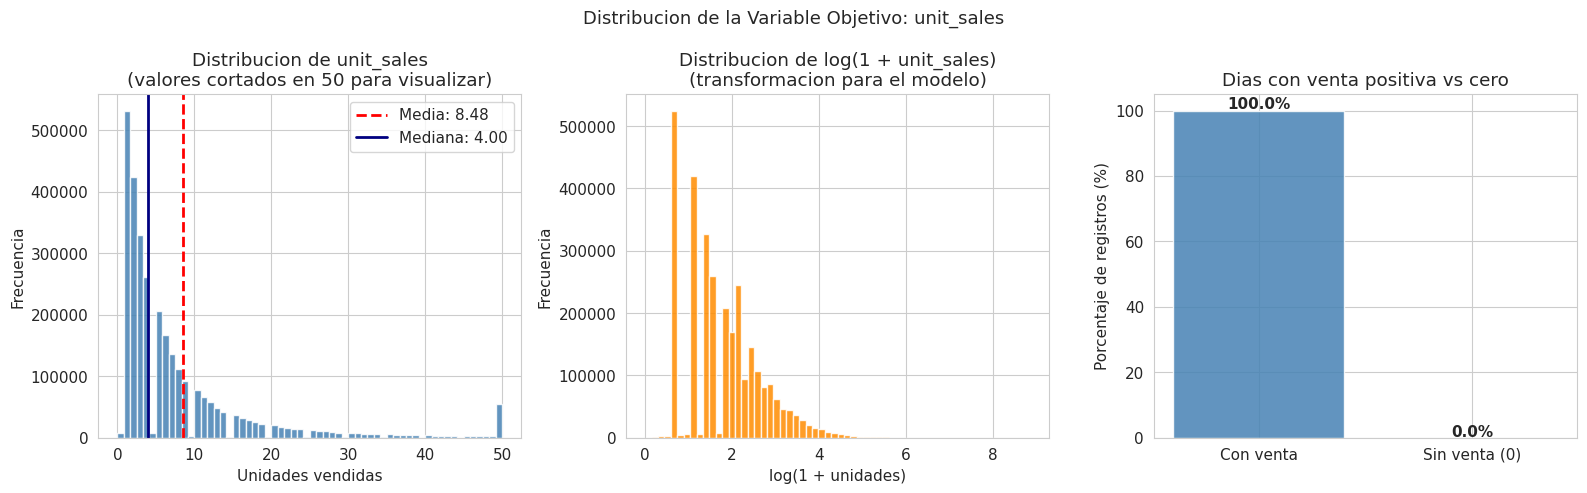

ESTADISTICAS DE UNIT_SALES:
  Media:     8.481
  Mediana:   4.000
  Asimetria: 73.63  (distribucion con cola larga hacia la derecha)
  P99:       66.0 unidades

CONCLUSION:
  La distribucion es muy asimetrica. La mayoria de los registros tienen
  ventas bajas pero hay algunos casos extremos con ventas muy altas.
  Para el modelado se aplica log(1+unit_sales) como variable objetivo.


In [ ]:
ventas = train['unit_sales']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribucion original (recortada en 50 para que el grafico sea legible)
axes[0].hist(ventas.clip(upper=50), bins=60,
             color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axvline(ventas.mean(),   color='red',  ls='--', lw=2,
                label=f'Media: {ventas.mean():.2f}')
axes[0].axvline(ventas.median(), color='navy', ls='-',  lw=2,
                label=f'Mediana: {ventas.median():.2f}')
axes[0].set_title('Distribucion de unit_sales\n(valores cortados en 50 para visualizar)')
axes[0].set_xlabel('Unidades vendidas')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Transformacion logaritmica
# log(1+x) se usa porque hay ceros y el log de 0 no existe
# La transformacion convierte la distribucion asimetrica en algo mas simetrico
# lo que mejora el rendimiento de los modelos de regresion
axes[1].hist(np.log1p(ventas), bins=60,
             color='darkorange', alpha=0.85, edgecolor='white')
axes[1].set_title('Distribucion de log(1 + unit_sales)\n(transformacion para el modelo)')
axes[1].set_xlabel('log(1 + unidades)')
axes[1].set_ylabel('Frecuencia')

# Proporcion de dias con venta cero
pct_cero = (ventas == 0).mean() * 100
axes[2].bar(['Con venta', 'Sin venta (0)'],
            [100 - pct_cero, pct_cero],
            color=['steelblue', 'lightgray'], alpha=0.85, edgecolor='white')
axes[2].set_title('Dias con venta positiva vs cero')
axes[2].set_ylabel('Porcentaje de registros (%)')
for i, v in enumerate([100 - pct_cero, pct_cero]):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Distribucion de la Variable Objetivo: unit_sales', fontsize=13)
plt.tight_layout()
plt.show()

print('ESTADISTICAS DE UNIT_SALES:')
print(f'  Media:     {ventas.mean():.3f}')
print(f'  Mediana:   {ventas.median():.3f}')
print(f'  Asimetria: {ventas.skew():.2f}  (distribucion con cola larga hacia la derecha)')
print(f'  P99:       {ventas.quantile(0.99):.1f} unidades')
print()
print('CONCLUSION:')
print('  La distribucion es muy asimetrica. La mayoria de los registros tienen')
print('  ventas bajas pero hay algunos casos extremos con ventas muy altas.')
print('  Para el modelado se aplica log(1+unit_sales) como variable objetivo.')

---
## Paso 5 - Analisis por familia de productos y perecibilidad

CATALOGO DE FAMILIAS DE PRODUCTOS:
                    family  total  perecibles  pct_perecible
                 GROCERY I   1334           0            0.0
                 BEVERAGES    613           0            0.0
                  CLEANING    446           0            0.0
                   PRODUCE    306         306          100.0
                     DAIRY    242         242          100.0
             PERSONAL CARE    153           0            0.0
              BREAD/BAKERY    134         134          100.0
                 HOME CARE    108           0            0.0
                      DELI     91          91          100.0
                     MEATS     84          84          100.0
        HOME AND KITCHEN I     77           0            0.0
          LIQUOR,WINE,BEER     73           0            0.0
              FROZEN FOODS     55           0            0.0
                   POULTRY     54          54          100.0
       HOME AND KITCHEN II     45           0     

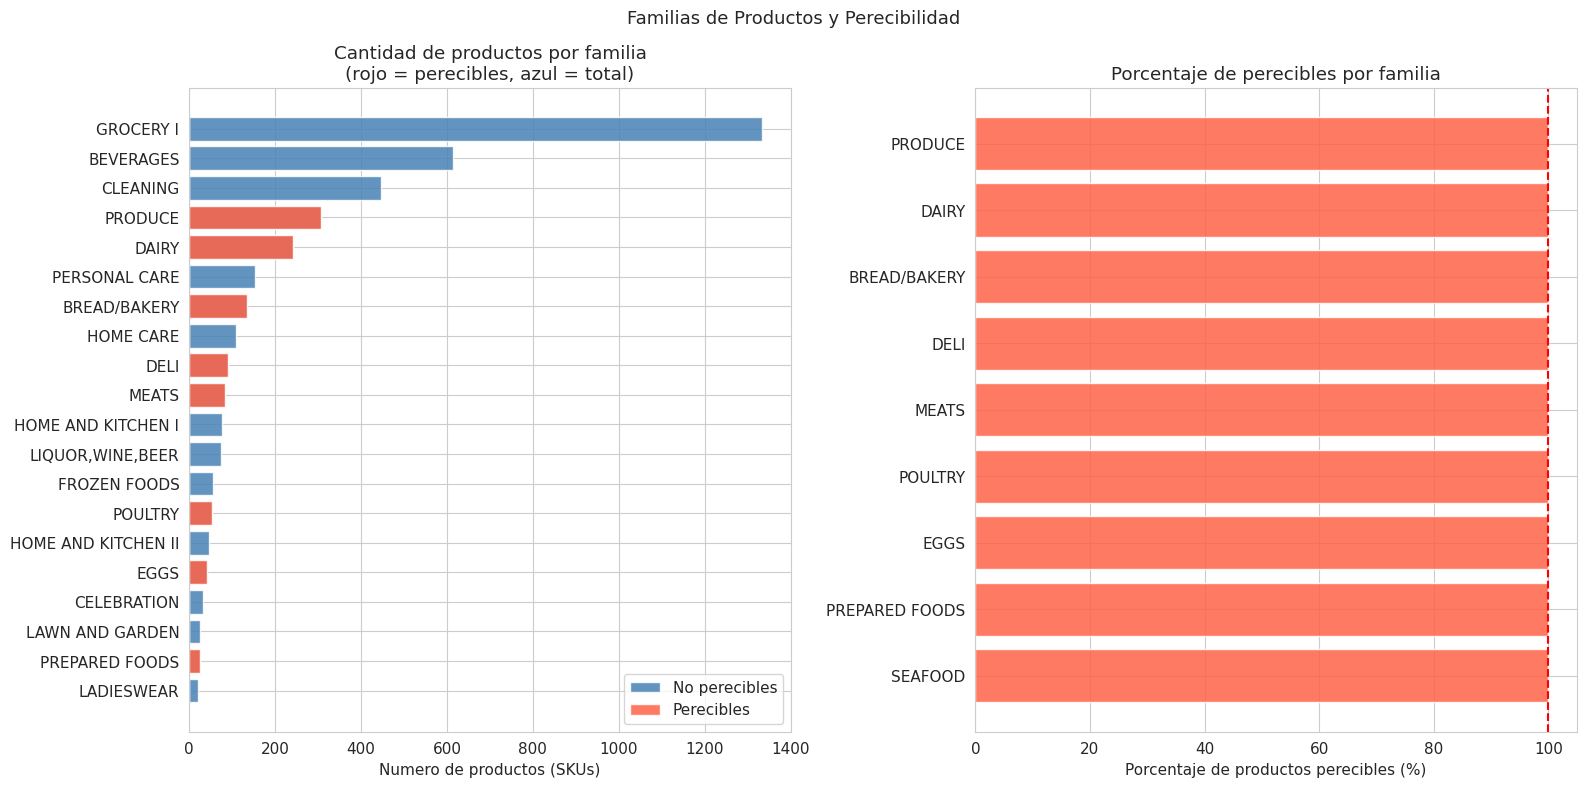

FAMILIAS 100% PERECIBLES (las mas criticas para ALDIMI):
  PRODUCE                   306 productos
  DAIRY                     242 productos
  BREAD/BAKERY              134 productos
  DELI                      91 productos
  MEATS                     84 productos
  POULTRY                   54 productos
  EGGS                      41 productos
  PREPARED FOODS            26 productos
  SEAFOOD                   8 productos

Total de productos perecibles: 986 de 4100 (24.0%)


In [ ]:
familia_res = (
    items.groupby('family')
    .agg(total=('item_nbr','count'), perecibles=('perishable','sum'))
    .sort_values('total', ascending=False)
    .reset_index()
)
familia_res['pct_perecible'] = (familia_res['perecibles'] / familia_res['total'] * 100).round(1)

print('CATALOGO DE FAMILIAS DE PRODUCTOS:')
print(familia_res.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_fam = familia_res.sort_values('total', ascending=True).tail(20)
axes[0].barh(top_fam['family'], top_fam['total'],
             color='steelblue', alpha=0.85, edgecolor='white', label='No perecibles')
axes[0].barh(top_fam['family'], top_fam['perecibles'],
             color='tomato', alpha=0.85, edgecolor='white', label='Perecibles')
axes[0].set_xlabel('Numero de productos (SKUs)')
axes[0].set_title('Cantidad de productos por familia\n(rojo = perecibles, azul = total)')
axes[0].legend()

solo_perec = familia_res[familia_res['perecibles'] > 0].sort_values('perecibles', ascending=True)
axes[1].barh(solo_perec['family'], solo_perec['pct_perecible'],
             color='tomato', alpha=0.85, edgecolor='white')
axes[1].axvline(100, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Porcentaje de productos perecibles (%)')
axes[1].set_title('Porcentaje de perecibles por familia')

plt.suptitle('Familias de Productos y Perecibilidad', fontsize=13)
plt.tight_layout()
plt.show()

print('FAMILIAS 100% PERECIBLES (las mas criticas para ALDIMI):')
for _, r in familia_res[familia_res['pct_perecible']==100].iterrows():
    print(f'  {r["family"]:<25} {int(r["perecibles"])} productos')

print(f'\nTotal de productos perecibles: {items["perishable"].sum()} de {len(items)} ({items["perishable"].mean()*100:.1f}%)')

---
## Paso 6 - Patrones temporales de transacciones

Las transacciones miden cuantas compras se realizaron por dia en cada tienda. Son un proxy del volumen de actividad y permiten analizar tendencias sin necesitar el train completo.

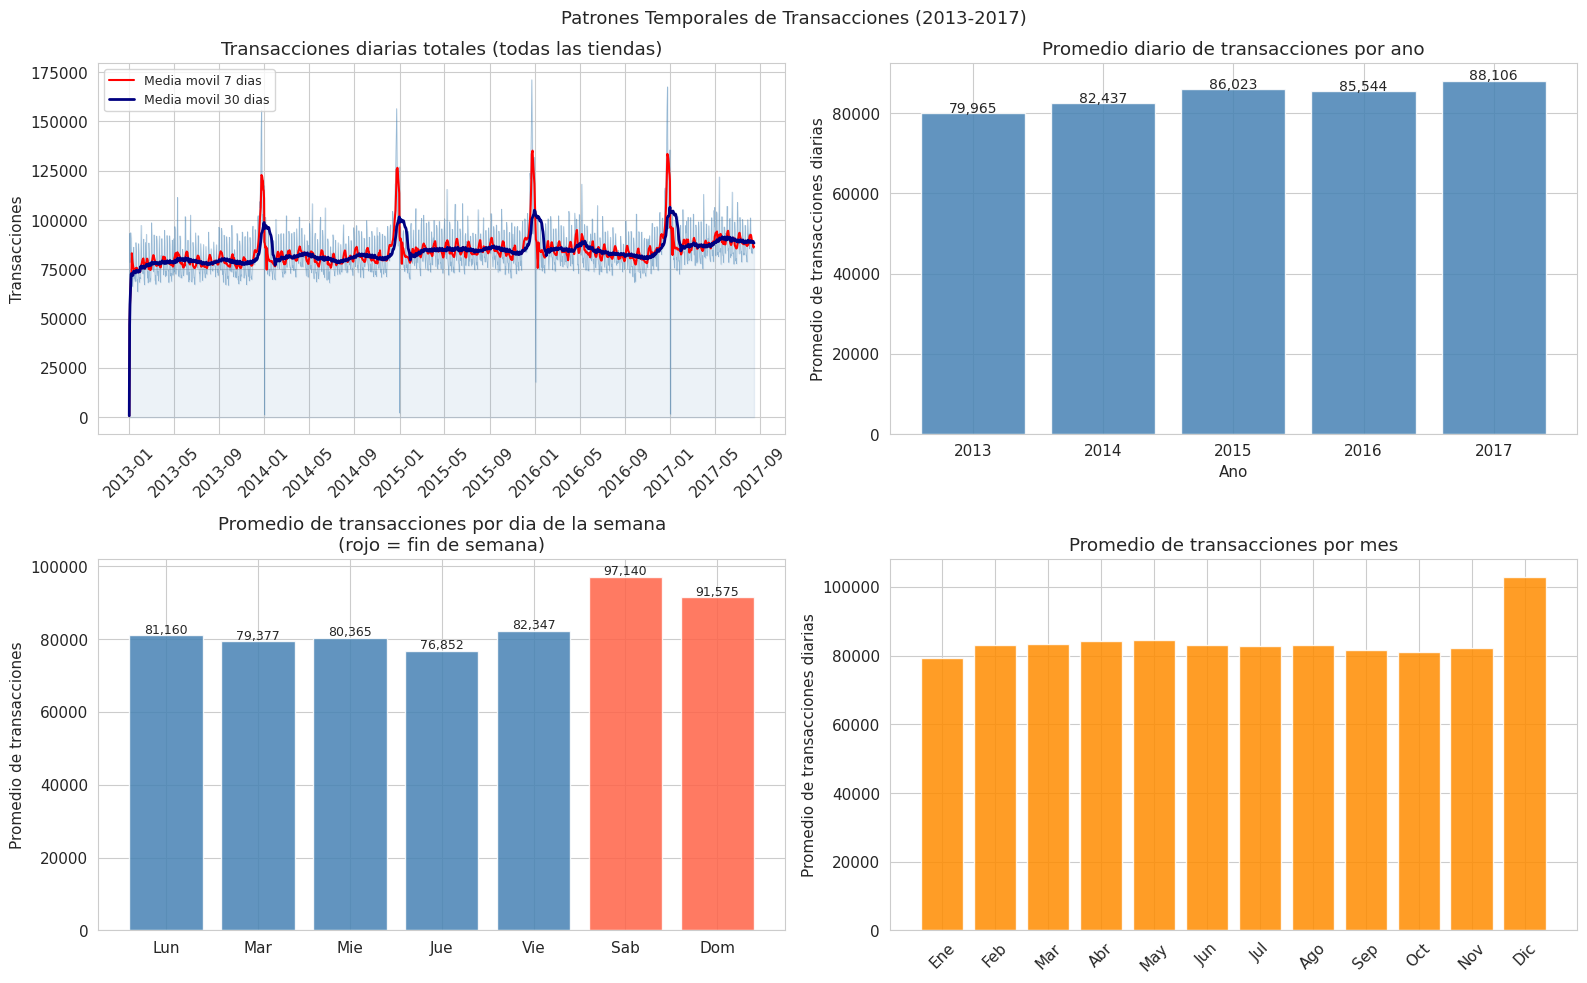

Dia con mas transacciones: Sab
Mes con mas transacciones: Dic
Crecimiento 2013 a 2016:   7.0%


In [ ]:
trans_dia = (
    transactions.groupby('date')['transactions'].sum().reset_index()
)
trans_dia['ma7']  = trans_dia['transactions'].rolling(7,  min_periods=1).mean()
trans_dia['ma30'] = trans_dia['transactions'].rolling(30, min_periods=1).mean()
trans_dia['anio'] = trans_dia['date'].dt.year
trans_dia['mes']  = trans_dia['date'].dt.month
trans_dia['dia']  = trans_dia['date'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Serie temporal completa
axes[0,0].fill_between(trans_dia['date'], trans_dia['transactions'], alpha=0.1, color='steelblue')
axes[0,0].plot(trans_dia['date'], trans_dia['transactions'], color='steelblue', lw=0.5, alpha=0.5)
axes[0,0].plot(trans_dia['date'], trans_dia['ma7'],  color='red',  lw=1.5, label='Media movil 7 dias')
axes[0,0].plot(trans_dia['date'], trans_dia['ma30'], color='navy', lw=2.0, label='Media movil 30 dias')
axes[0,0].set_title('Transacciones diarias totales (todas las tiendas)')
axes[0,0].set_ylabel('Transacciones')
axes[0,0].legend(fontsize=9)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0,0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45)

# Por anio
txanio = trans_dia.groupby('anio')['transactions'].mean()
axes[0,1].bar(txanio.index, txanio.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0,1].set_title('Promedio diario de transacciones por ano')
axes[0,1].set_ylabel('Promedio de transacciones diarias')
axes[0,1].set_xlabel('Ano')
for x, y in zip(txanio.index, txanio.values):
    axes[0,1].text(x, y + 200, f'{y:,.0f}', ha='center', fontsize=10)

# Por dia de la semana
dias_nombres = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
txdia = trans_dia.groupby('dia')['transactions'].mean()
colores_dia = ['tomato' if d >= 5 else 'steelblue' for d in range(7)]
axes[1,0].bar(dias_nombres, txdia.values, color=colores_dia, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Promedio de transacciones por dia de la semana\n(rojo = fin de semana)')
axes[1,0].set_ylabel('Promedio de transacciones')
for i, v in enumerate(txdia.values):
    axes[1,0].text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=9)

# Por mes
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
txmes = trans_dia.groupby('mes')['transactions'].mean()
axes[1,1].bar(meses_nombres[:len(txmes)], txmes.values, color='darkorange', alpha=0.85, edgecolor='white')
axes[1,1].set_title('Promedio de transacciones por mes')
axes[1,1].set_ylabel('Promedio de transacciones diarias')
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Patrones Temporales de Transacciones (2013-2017)', fontsize=13)
plt.tight_layout()
plt.show()

dia_max = dias_nombres[int(txdia.idxmax())]
mes_max = meses_nombres[int(txmes.idxmax()) - 1]
print(f'Dia con mas transacciones: {dia_max}')
print(f'Mes con mas transacciones: {mes_max}')
print(f'Crecimiento 2013 a 2016:   {(txanio.loc[2016]/txanio.loc[2013]-1)*100:.1f}%')

---
## Paso 7 - Analisis de tiendas

DISTRIBUCION DE TIENDAS:
  Total tiendas: 54
  Ciudades:      22

Por tipo de tienda (A = grande, E = pequena):
type
D    18
C    15
A     9
B     8
E     4


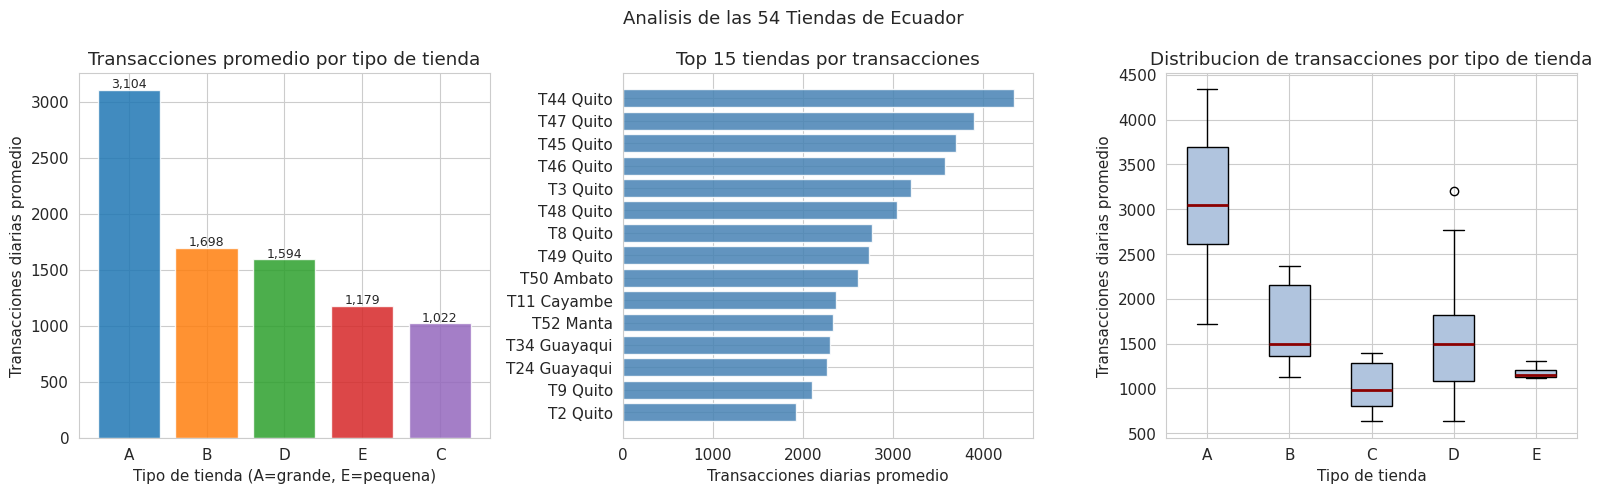

In [ ]:
print('DISTRIBUCION DE TIENDAS:')
print(f'  Total tiendas: {len(stores)}')
print(f'  Ciudades:      {stores["city"].nunique()}')
print()
print('Por tipo de tienda (A = grande, E = pequena):')
print(stores['type'].value_counts().to_string())

trans_tienda = (
    transactions.groupby('store_nbr')['transactions'].mean().reset_index()
    .merge(stores[['store_nbr','city','type']], on='store_nbr')
    .sort_values('transactions', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Por tipo
ttipo = trans_tienda.groupby('type')['transactions'].mean().sort_values(ascending=False)
axes[0].bar(ttipo.index, ttipo.values,
            color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd'][:len(ttipo)],
            alpha=0.85, edgecolor='white')
axes[0].set_title('Transacciones promedio por tipo de tienda')
axes[0].set_ylabel('Transacciones diarias promedio')
axes[0].set_xlabel('Tipo de tienda (A=grande, E=pequena)')
for i, v in enumerate(ttipo.values):
    axes[0].text(i, v + 20, f'{v:,.0f}', ha='center', fontsize=9)

# Top 15 tiendas
top15 = trans_tienda.head(15)
axes[1].barh(
    [f'T{int(r["store_nbr"])} {r["city"][:8]}' for _, r in top15.iterrows()],
    top15['transactions'],
    color='steelblue', alpha=0.85, edgecolor='white'
)
axes[1].set_xlabel('Transacciones diarias promedio')
axes[1].set_title('Top 15 tiendas por transacciones')
axes[1].invert_yaxis()

# Boxplot por tipo
tipos_ord = sorted(trans_tienda['type'].unique())
axes[2].boxplot(
    [trans_tienda[trans_tienda['type']==t]['transactions'].values for t in tipos_ord],
    labels=tipos_ord,
    patch_artist=True,
    boxprops={'facecolor': 'lightsteelblue'},
    medianprops={'color': 'darkred', 'linewidth': 2}
)
axes[2].set_title('Distribucion de transacciones por tipo de tienda')
axes[2].set_ylabel('Transacciones diarias promedio')
axes[2].set_xlabel('Tipo de tienda')

plt.suptitle('Analisis de las 54 Tiendas de Ecuador', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 8 - Analisis de festivos y su efecto en las transacciones

TIPOS DE FESTIVOS Y EVENTOS:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5

ALCANCE GEOGRAFICO:
locale
National    174
Local       152
Regional     24


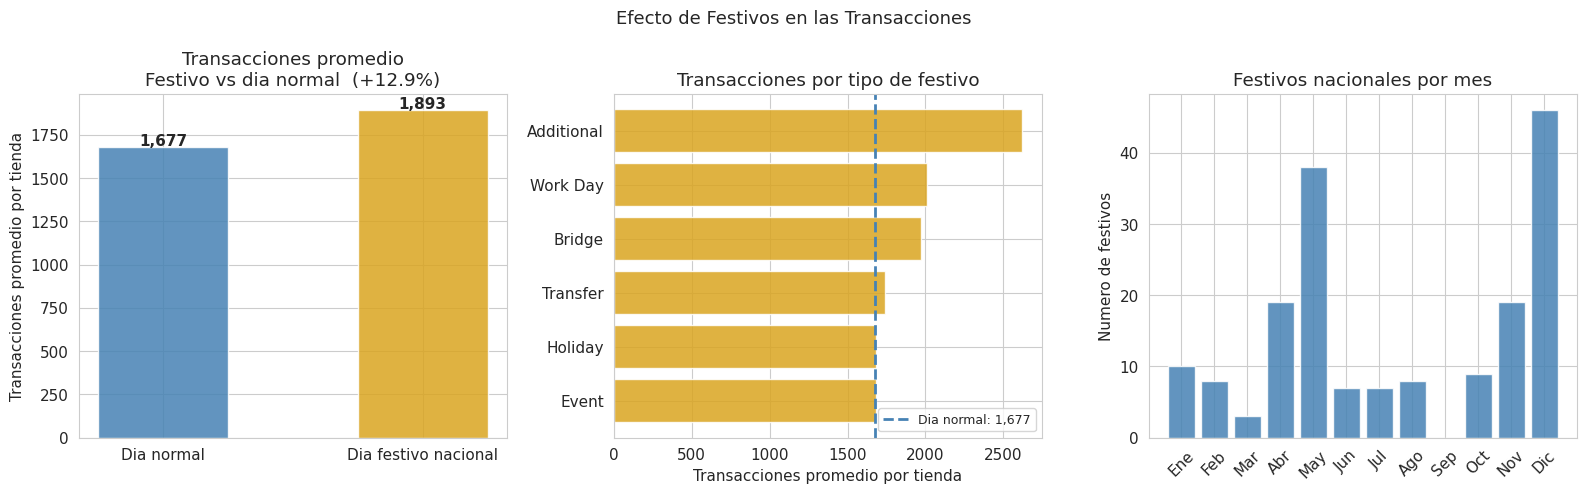

Diferencia festivo vs dia normal: +12.9%
En festivos tipo Holiday las tiendas tienen menos trafico.
En festivos tipo Event el comportamiento puede ser el opuesto (compras previas al evento).


In [ ]:
print('TIPOS DE FESTIVOS Y EVENTOS:')
print(holidays['type'].value_counts().to_string())
print()
print('ALCANCE GEOGRAFICO:')
print(holidays['locale'].value_counts().to_string())

# Unir festivos nacionales con transacciones
festivales_nac = holidays[holidays['locale']=='National'][['date','type']].drop_duplicates('date')
trans_fest = transactions.merge(festivales_nac, on='date', how='left')
trans_fest['es_festivo'] = trans_fest['type'].notna()
efecto = trans_fest.groupby('es_festivo')['transactions'].mean()
diferencia = (efecto[True] / efecto[False] - 1) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Festivo vs dia normal
axes[0].bar(['Dia normal', 'Dia festivo nacional'],
            [efecto[False], efecto[True]],
            color=['steelblue', 'goldenrod'], alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_title(f'Transacciones promedio\nFestivo vs dia normal  ({diferencia:+.1f}%)')
axes[0].set_ylabel('Transacciones promedio por tienda')
for i, v in enumerate([efecto[False], efecto[True]]):
    axes[0].text(i, v + 10, f'{v:,.0f}', ha='center', fontweight='bold')

# Por tipo de festivo
ef_tipo = (
    trans_fest[trans_fest['es_festivo']]
    .groupby('type')['transactions'].mean().sort_values()
)
axes[1].barh(ef_tipo.index, ef_tipo.values, color='goldenrod', alpha=0.85, edgecolor='white')
axes[1].axvline(efecto[False], color='steelblue', ls='--', lw=2,
                label=f'Dia normal: {efecto[False]:,.0f}')
axes[1].set_xlabel('Transacciones promedio por tienda')
axes[1].set_title('Transacciones por tipo de festivo')
axes[1].legend(fontsize=9)

# Festivos por mes
hmes = holidays[holidays['locale']=='National'].copy()
hmes['mes'] = hmes['date'].dt.month
conteo_mes = hmes['mes'].value_counts().sort_index()
axes[2].bar(meses_nombres[:12], [conteo_mes.get(m,0) for m in range(1,13)],
            color='steelblue', alpha=0.85, edgecolor='white')
axes[2].set_title('Festivos nacionales por mes')
axes[2].set_ylabel('Numero de festivos')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Efecto de Festivos en las Transacciones', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Diferencia festivo vs dia normal: {diferencia:+.1f}%')
print('En festivos tipo Holiday las tiendas tienen menos trafico.')
print('En festivos tipo Event el comportamiento puede ser el opuesto (compras previas al evento).')

---
## Paso 9 - Precio del petroleo como variable economica

Ecuador depende de las exportaciones de petroleo. Cuando el precio cae, el gobierno recorta gasto, el consumo baja y eso se refleja en las ventas del supermercado.

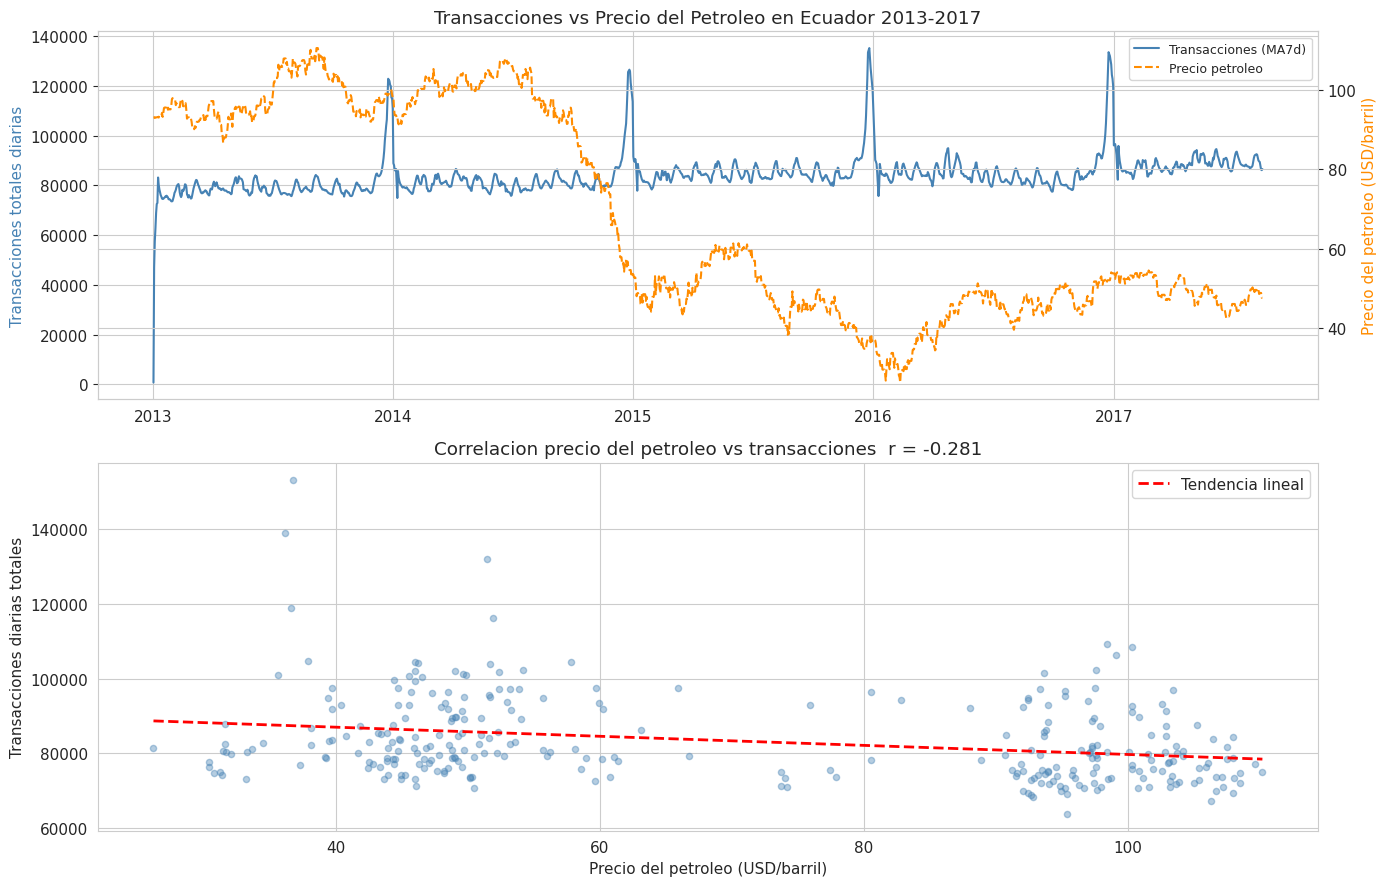

Correlacion de Pearson: -0.2813
Precio minimo del periodo: 26.19 USD
Precio maximo del periodo: 110.62 USD


In [ ]:
trans_oil = transactions.merge(oil, on='date', how='left')
trans_oil['dcoilwtico'] = trans_oil['dcoilwtico'].fillna(method='ffill')
toil_dia = trans_oil.groupby('date').agg(
    trans=('transactions','sum'), oil=('dcoilwtico','mean')
).reset_index()
toil_dia['ma7'] = toil_dia['trans'].rolling(7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Serie doble eje
ax2 = axes[0].twinx()
axes[0].plot(toil_dia['date'], toil_dia['ma7'], color='steelblue', lw=1.5, label='Transacciones (MA7d)')
ax2.plot(toil_dia['date'], toil_dia['oil'], color='darkorange', lw=1.5, ls='--', label='Precio petroleo')
axes[0].set_ylabel('Transacciones totales diarias', color='steelblue')
ax2.set_ylabel('Precio del petroleo (USD/barril)', color='darkorange')
axes[0].set_title('Transacciones vs Precio del Petroleo en Ecuador 2013-2017')
l1, e1 = axes[0].get_legend_handles_labels()
l2, e2 = ax2.get_legend_handles_labels()
axes[0].legend(l1+l2, e1+e2, fontsize=9)

# Correlacion scatter
muestra_oil = toil_dia.dropna().sample(min(300, len(toil_dia)), random_state=SEED)
axes[1].scatter(muestra_oil['oil'], muestra_oil['trans'], alpha=0.4, s=20, color='steelblue')
z = np.polyfit(muestra_oil['oil'], muestra_oil['trans'], 1)
xrng = np.linspace(muestra_oil['oil'].min(), muestra_oil['oil'].max(), 100)
axes[1].plot(xrng, np.poly1d(z)(xrng), 'r--', lw=2, label='Tendencia lineal')
corr = muestra_oil['oil'].corr(muestra_oil['trans'])
axes[1].set_xlabel('Precio del petroleo (USD/barril)')
axes[1].set_ylabel('Transacciones diarias totales')
axes[1].set_title(f'Correlacion precio del petroleo vs transacciones  r = {corr:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Correlacion de Pearson: {corr:.4f}')
print(f'Precio minimo del periodo: {oil["dcoilwtico"].min():.2f} USD')
print(f'Precio maximo del periodo: {oil["dcoilwtico"].max():.2f} USD')

---
## Paso 10 - Analisis de correlaciones

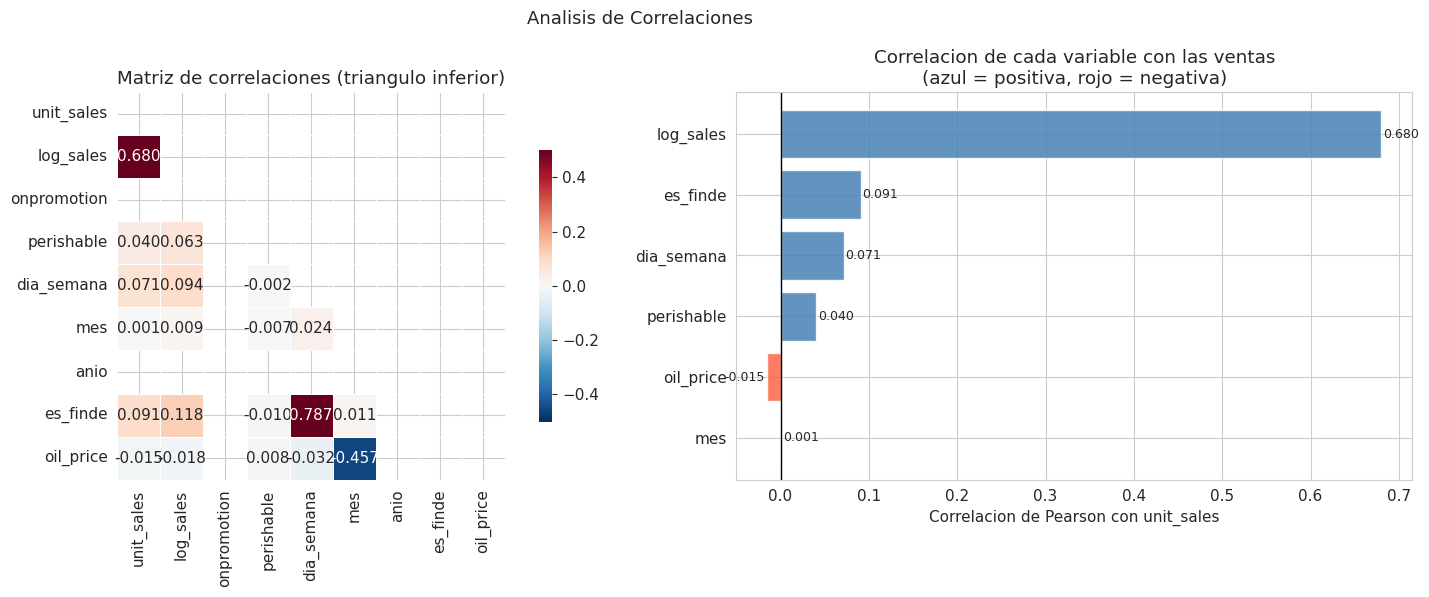

CORRELACIONES CON UNIT_SALES (por magnitud):
log_sales      0.6802
es_finde       0.0906
dia_semana     0.0715
perishable     0.0401
oil_price      0.0153
mes            0.0014
onpromotion       NaN
anio              NaN

Las correlaciones individuales son bajas porque la demanda depende
de muchas variables interactuando. Esto es normal en datos de retail
y no significa que las variables no aporten al modelo.


In [ ]:
muestra_c = train.sample(min(50000, len(train)), random_state=SEED).copy()
muestra_c = muestra_c.merge(oil.rename(columns={'dcoilwtico':'oil_price'}), on='date', how='left')
muestra_c['dia_semana'] = muestra_c['date'].dt.dayofweek
muestra_c['mes']        = muestra_c['date'].dt.month
muestra_c['anio']       = muestra_c['date'].dt.year
muestra_c['es_finde']   = (muestra_c['dia_semana'] >= 5).astype(int)
muestra_c['log_sales']  = np.log1p(muestra_c['unit_sales'])
muestra_c['onpromotion']= muestra_c['onpromotion'].astype(float)

cols_corr = ['unit_sales','log_sales','onpromotion','perishable',
             'dia_semana','mes','anio','es_finde','oil_price']
mat_corr = muestra_c[cols_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(mat_corr, dtype=bool))
sns.heatmap(mat_corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.7})
axes[0].set_title('Matriz de correlaciones (triangulo inferior)')

corr_target = mat_corr['unit_sales'].drop('unit_sales').sort_values(key=abs, ascending=True)
colores_c = ['tomato' if v < 0 else 'steelblue' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colores_c, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Correlacion de Pearson con unit_sales')
axes[1].set_title('Correlacion de cada variable con las ventas\n(azul = positiva, rojo = negativa)')
for i, v in enumerate(corr_target.values):
    axes[1].text(v + 0.002*np.sign(v), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('Analisis de Correlaciones', fontsize=13)
plt.tight_layout()
plt.show()

print('CORRELACIONES CON UNIT_SALES (por magnitud):')
print(corr_target.abs().sort_values(ascending=False).round(4).to_string())
print()
print('Las correlaciones individuales son bajas porque la demanda depende')
print('de muchas variables interactuando. Esto es normal en datos de retail')
print('y no significa que las variables no aporten al modelo.')

---
## Paso 11 - Deteccion y tratamiento de outliers

DETECCION DE OUTLIERS - Metodo IQR factor 3.0
  Q1:              2.000
  Q3:              9.000
  IQR:             7.000
  Limite superior: 30.000
  Outliers:        133,630 registros (4.45%)


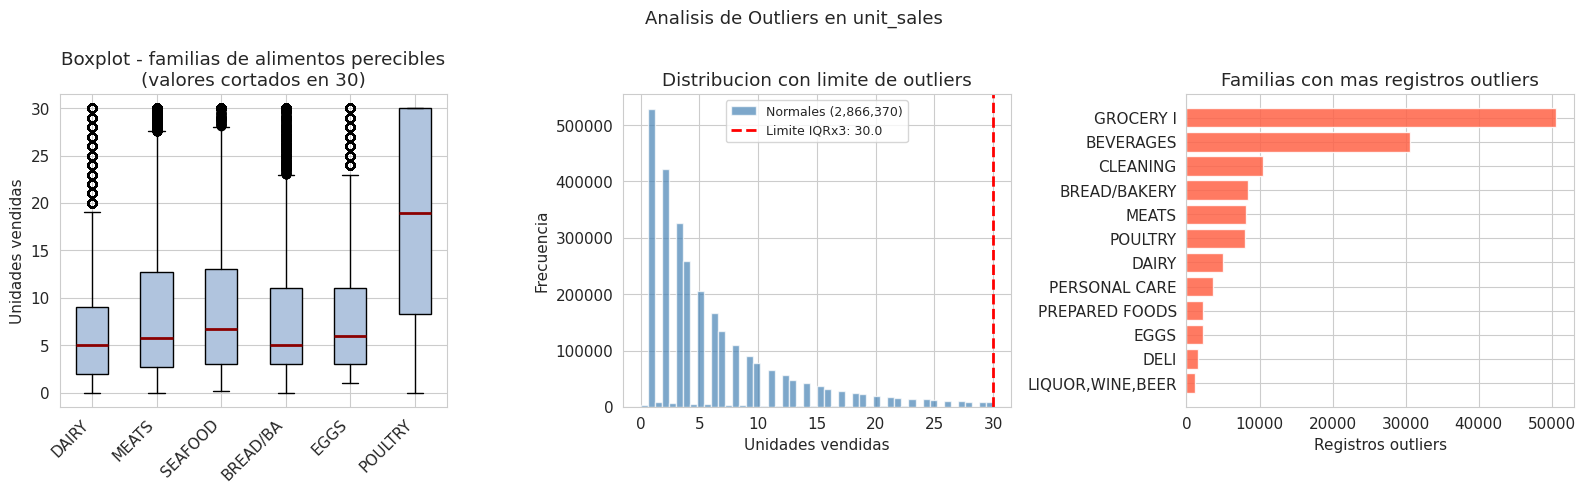

Decision: winsorizacion en 30.0 unidades
Los valores mayores al limite se reemplazan por el limite.
No se eliminan filas: se perderian datos reales de alta demanda en festivos.


In [ ]:
Q1  = ventas.quantile(0.25)
Q3  = ventas.quantile(0.75)
IQR = Q3 - Q1
# Se usa factor 3.0 en lugar del estandar 1.5
# Con factor 1.5 se marcarian como outliers los picos de festivos y promociones
# que son eventos reales de alta demanda, no errores de medicion.
# Factor 3.0 solo marca los valores verdaderamente extremos.
FACTOR = 3.0
lim_sup = Q3 + FACTOR * IQR
outliers = train[train['unit_sales'] > lim_sup]
pct_out  = len(outliers) / len(train) * 100

print('DETECCION DE OUTLIERS - Metodo IQR factor 3.0')
print(f'  Q1:              {Q1:.3f}')
print(f'  Q3:              {Q3:.3f}')
print(f'  IQR:             {IQR:.3f}')
print(f'  Limite superior: {lim_sup:.3f}')
print(f'  Outliers:        {len(outliers):,} registros ({pct_out:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot por familia perecible
fams_perec = [f for f in ['PRODUCE','DAIRY','MEATS','SEAFOOD','BREAD/BAKERY','EGGS','POULTRY']
              if f in train['family'].values]
data_box = [train[train['family']==f]['unit_sales'].clip(upper=30) for f in fams_perec]
axes[0].boxplot(data_box, labels=[f[:8] for f in fams_perec],
                patch_artist=True,
                boxprops={'facecolor': 'lightsteelblue'},
                medianprops={'color': 'darkred', 'linewidth': 2})
axes[0].set_title('Boxplot - familias de alimentos perecibles\n(valores cortados en 30)')
axes[0].set_ylabel('Unidades vendidas')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Limite outlier
axes[1].hist(ventas[ventas <= lim_sup].clip(upper=50), bins=50,
             color='steelblue', alpha=0.7, edgecolor='white',
             label=f'Normales ({(ventas <= lim_sup).sum():,})')
axes[1].axvline(lim_sup, color='red', ls='--', lw=2, label=f'Limite IQRx3: {lim_sup:.1f}')
axes[1].set_title('Distribucion con limite de outliers')
axes[1].set_xlabel('Unidades vendidas')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)

# Outliers por familia
out_fam = outliers['family'].value_counts().head(12)
axes[2].barh(out_fam.index, out_fam.values, color='tomato', alpha=0.85, edgecolor='white')
axes[2].set_xlabel('Registros outliers')
axes[2].set_title('Familias con mas registros outliers')
axes[2].invert_yaxis()

plt.suptitle('Analisis de Outliers en unit_sales', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Decision: winsorizacion en {lim_sup:.1f} unidades')
print('Los valores mayores al limite se reemplazan por el limite.')
print('No se eliminan filas: se perderian datos reales de alta demanda en festivos.')

---
## Paso 12 - Subset de familias relevantes para ALDIMI

SUBSET ALDIMI:
  Productos:    3,002 de 4,100 (73.2%)
  Registros:    2,278,160 de 3,000,000 (75.9%)
  Perecibles:   28.8%
  Familias:     12


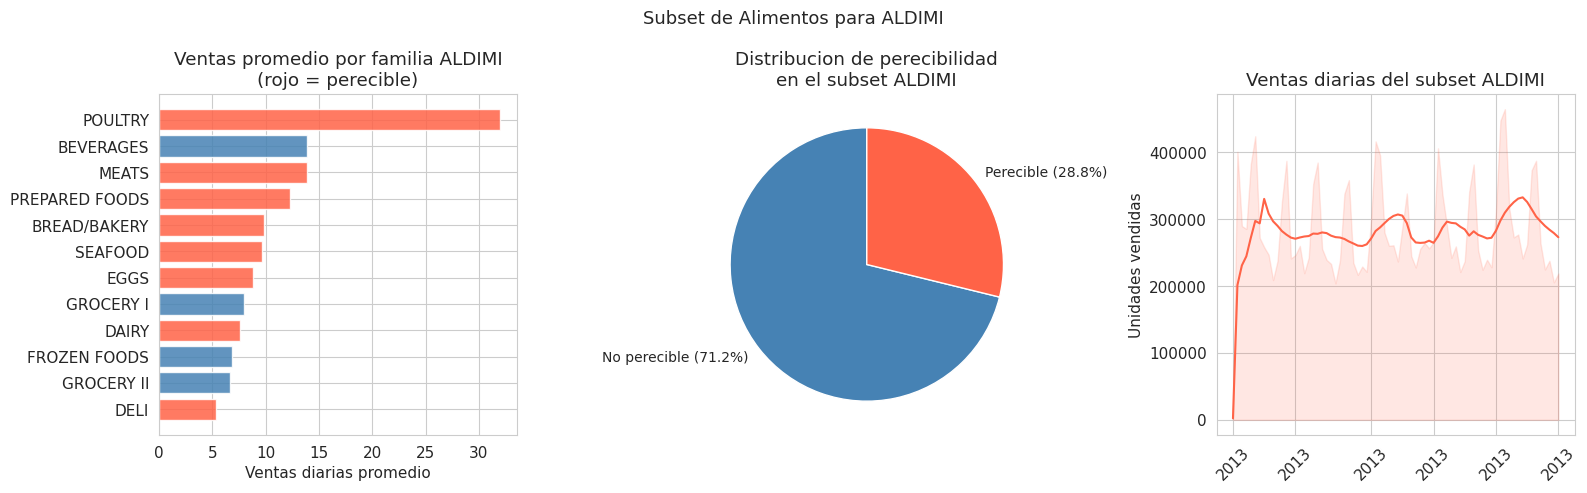

In [ ]:
FAMILIAS_ALDIMI = [
    'PRODUCE', 'MEATS', 'SEAFOOD', 'DAIRY', 'FROZEN FOODS',
    'BREAD/BAKERY', 'EGGS', 'POULTRY', 'BEVERAGES',
    'GROCERY I', 'GROCERY II', 'DELI', 'PREPARED FOODS',
]

items_ald  = items[items['family'].isin(FAMILIAS_ALDIMI)]
train_ald  = train[train['family'].isin(FAMILIAS_ALDIMI)].copy()

print('SUBSET ALDIMI:')
print(f'  Productos:    {len(items_ald):,} de {len(items):,} ({len(items_ald)/len(items)*100:.1f}%)')
print(f'  Registros:    {len(train_ald):,} de {len(train):,} ({len(train_ald)/len(train)*100:.1f}%)')
print(f'  Perecibles:   {train_ald["perishable"].mean()*100:.1f}%')
print(f'  Familias:     {train_ald["family"].nunique()}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ventas por familia del subset
vald = (
    train_ald.groupby(['family','perishable'])['unit_sales'].mean()
    .reset_index().sort_values('unit_sales', ascending=True)
)
col_p = ['tomato' if p == 1 else 'steelblue' for p in vald['perishable']]
axes[0].barh(vald['family'], vald['unit_sales'], color=col_p, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Ventas diarias promedio')
axes[0].set_title('Ventas promedio por familia ALDIMI\n(rojo = perecible)')

# Proporcion perecible
cp = train_ald['perishable'].value_counts()
axes[1].pie(
    cp.values,
    labels=[f'No perecible ({cp.get(0,0)/len(train_ald)*100:.1f}%)',
            f'Perecible ({cp.get(1,0)/len(train_ald)*100:.1f}%)'],
    colors=['steelblue','tomato'], startangle=90,
    textprops={'fontsize': 10}
)
axes[1].set_title('Distribucion de perecibilidad\nen el subset ALDIMI')

# Serie temporal del subset
daily_ald = train_ald.groupby('date')['unit_sales'].sum().reset_index()
daily_ald['ma7'] = daily_ald['unit_sales'].rolling(7, min_periods=1).mean()
axes[2].fill_between(daily_ald['date'], daily_ald['unit_sales'], alpha=0.15, color='tomato')
axes[2].plot(daily_ald['date'], daily_ald['ma7'], color='tomato', lw=1.5)
axes[2].set_title('Ventas diarias del subset ALDIMI')
axes[2].set_ylabel('Unidades vendidas')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Subset de Alimentos para ALDIMI', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 13 - Construccion de variables objetivo

Las tres variables objetivo del proyecto se construyen directamente desde los datos disponibles.

VARIABLES OBJETIVO DEL PROYECTO

demand7[t]  = sum(unit_sales[t+1] ... unit_sales[t+7])
             suma acumulada de los 7 dias siguientes

demand14[t] = sum(unit_sales[t+1] ... unit_sales[t+14])
             suma acumulada de los 14 dias siguientes

perece      = items.perishable
             columna disponible directamente en items.csv (0 o 1)

Ejemplo: tienda 1, item 103520
      date  unit_sales  demand7  demand14
2013-01-04         2.0     18.0      36.0
2013-01-05         3.0     16.0      38.0
2013-01-07         2.0     17.0      38.0
2013-01-08         6.0     14.0      35.0
2013-01-09         3.0     12.0      36.0
2013-01-10         1.0     13.0      36.0
2013-01-11         2.0     14.0      36.0
2013-01-12         1.0     18.0      36.0

Ratio demand14/demand7: 2.050  (esperado ~2.0)
Los targets son coherentes


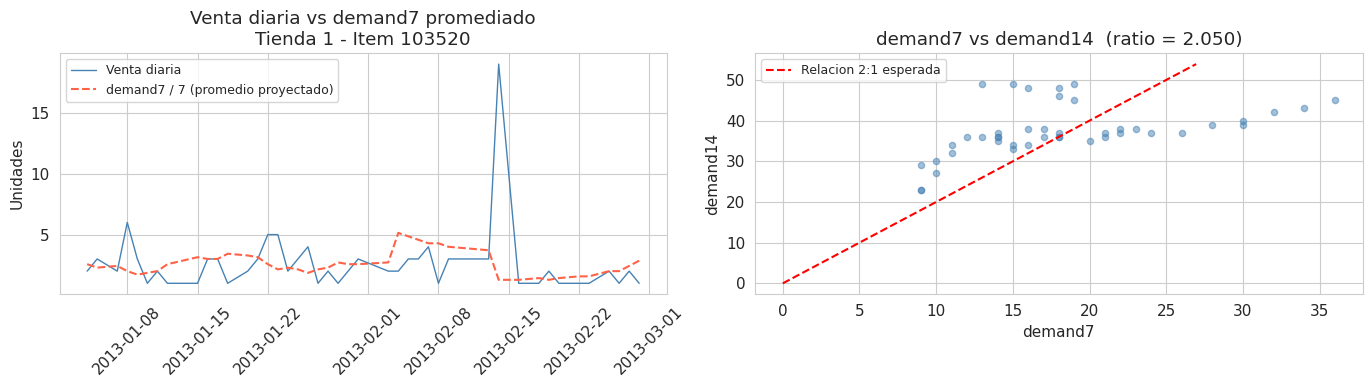

In [ ]:
print('VARIABLES OBJETIVO DEL PROYECTO')
print('=' * 60)
print()
print('demand7[t]  = sum(unit_sales[t+1] ... unit_sales[t+7])')
print('             suma acumulada de los 7 dias siguientes')
print()
print('demand14[t] = sum(unit_sales[t+1] ... unit_sales[t+14])')
print('             suma acumulada de los 14 dias siguientes')
print()
print('perece      = items.perishable')
print('             columna disponible directamente en items.csv (0 o 1)')
print()

# Demostrar construccion en una serie de ejemplo
conteo_serie = train_ald.groupby(['store_nbr','item_nbr']).size()
serie_ej = conteo_serie[conteo_serie >= 30].index[0]
store_ej, item_ej = serie_ej

serie = (
    train_ald[
        (train_ald['store_nbr']==store_ej) &
        (train_ald['item_nbr']==item_ej)
    ]
    .sort_values('date').copy()
)

serie['demand7']  = serie['unit_sales'].shift(-1).rolling(7,  min_periods=4).sum().shift(-6)
serie['demand14'] = serie['unit_sales'].shift(-1).rolling(14, min_periods=8).sum().shift(-13)
serie_c = serie.dropna(subset=['demand7','demand14'])

print(f'Ejemplo: tienda {store_ej}, item {item_ej}')
print(serie_c[['date','unit_sales','demand7','demand14']].head(8).to_string(index=False))

ratio = serie_c['demand14'].mean() / serie_c['demand7'].mean()
print(f'\nRatio demand14/demand7: {ratio:.3f}  (esperado ~2.0)')
print('Los targets son coherentes' if 1.7 < ratio < 2.3 else 'Revisar el calculo')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(serie_c['date'], serie_c['unit_sales'], label='Venta diaria', color='steelblue', lw=1)
axes[0].plot(serie_c['date'], serie_c['demand7']/7, label='demand7 / 7 (promedio proyectado)',
             color='tomato', lw=1.5, ls='--')
axes[0].set_title(f'Venta diaria vs demand7 promediado\nTienda {store_ej} - Item {item_ej}')
axes[0].set_ylabel('Unidades')
axes[0].legend(fontsize=9)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].scatter(serie_c['demand7'], serie_c['demand14'], alpha=0.5, s=20, color='steelblue')
lim = serie_c['demand14'].max() * 1.1
axes[1].plot([0, lim/2], [0, lim], 'r--', lw=1.5, label='Relacion 2:1 esperada')
axes[1].set_xlabel('demand7')
axes[1].set_ylabel('demand14')
axes[1].set_title(f'demand7 vs demand14  (ratio = {ratio:.3f})')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()